# Optimizing Store Performance Through Data-Driven Insights

## Objective
Identify factors that influence store performance and provide actionable insights to improve sales.

## Dataset Overview
The dataset includes store features such as temperature, fuel price, promotions, CPI, and unemployment metrics along with store type and size.

## Workflow
1. Load and explore the dataset
2. Clean and preprocess the data
3. Perform exploratory data analysis
4. Build regression models
5. Evaluate and interpret results

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
# Load dataset

store_data = pd.read_csv('features.csv')

# Display first 5 rows

store_data.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
print(store_data.columns)

print(store_data.shape)

store_data.info()

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')
(8190, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [5]:
store_data.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')

## Data Preprocessing
- Convert date columns
- Handle missing values
- Encode categorical variables

In [6]:
# Convert Date column into datetime format

store_data['Date'] = pd.to_datetime(store_data['Date'])

# Check datatype

print(store_data['Date'].dtype)



# Check missing values

print(store_data.isnull().sum())

# Fill missing numeric values with median

store_data = store_data.fillna(store_data.median(numeric_only=True))


datetime64[ns]
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


In [7]:
# Convert IsHoliday column into numeric values

store_data['IsHoliday'] = store_data['IsHoliday'].astype(int)

# Check first few rows

store_data.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,4743.58,364.57,36.26,1176.425,2727.135,211.096358,8.106,0
1,1,2010-02-12,38.51,2.548,4743.58,364.57,36.26,1176.425,2727.135,211.242170,8.106,1
2,1,2010-02-19,39.93,2.514,4743.58,364.57,36.26,1176.425,2727.135,211.289143,8.106,0
3,1,2010-02-26,46.63,2.561,4743.58,364.57,36.26,1176.425,2727.135,211.319643,8.106,0
4,1,2010-03-05,46.50,2.625,4743.58,364.57,36.26,1176.425,2727.135,211.350143,8.106,0


### Exploratory Data Analysis

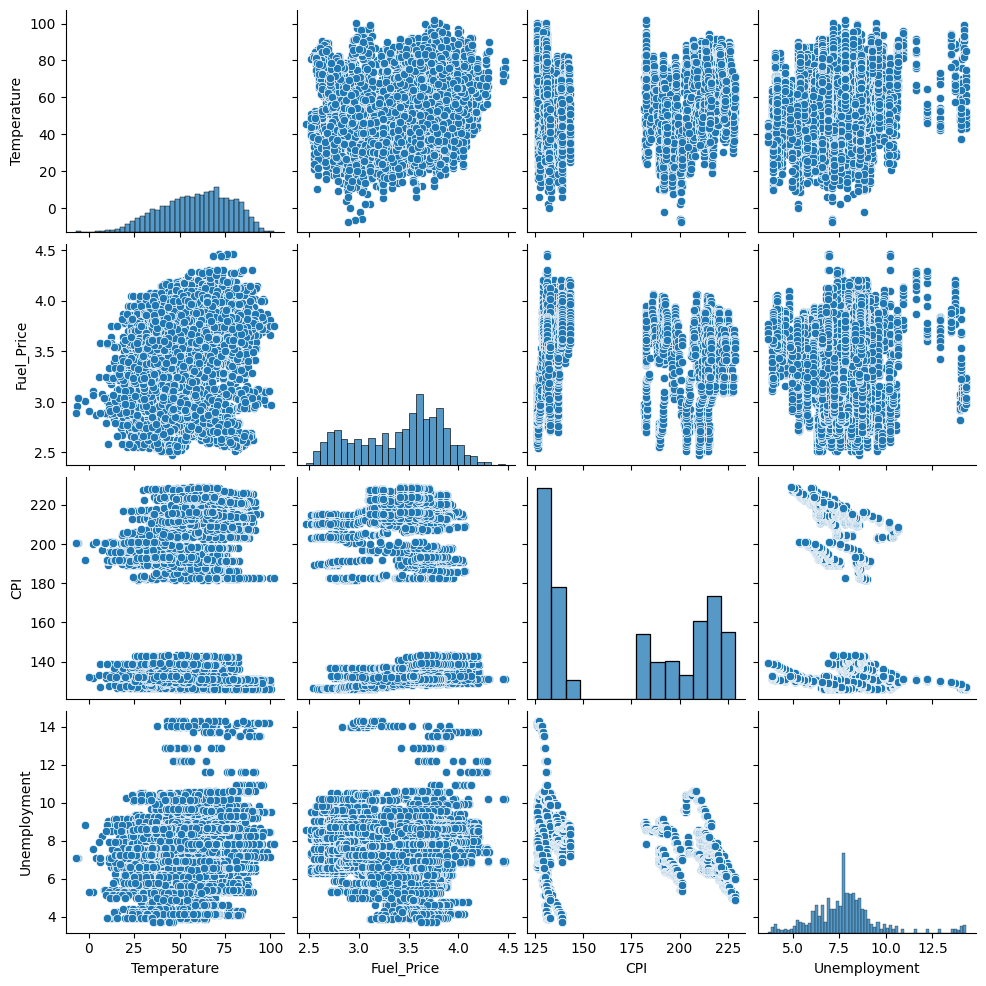

In [8]:
# Pairplot for important numerical variables

selected_columns = [
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment'
]

sns.pairplot(store_data[selected_columns])

plt.show()

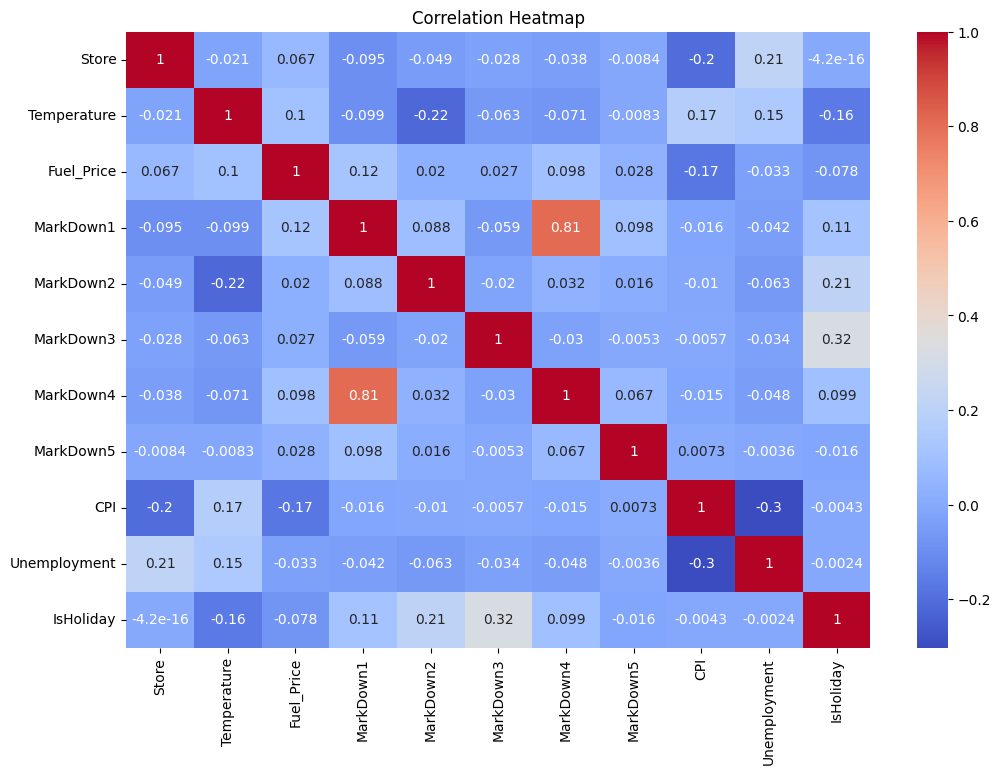

In [9]:
# Correlation heatmap

plt.figure(figsize=(12,8))

correlation_matrix = store_data.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

## Modeling
Train a Linear Regression model to predict CPI or other target depending on availability.

In [10]:
# Define features (independent variables)

X = store_data[[
    'Temperature',
    'Fuel_Price',
    'Unemployment',
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]]

# Define target variable

y = store_data['CPI']

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

# Make predictions

predictions = model.predict(X_test)

# Evaluate the model

mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Squared Error: 1296.418064171898
R2 Score: 0.13855585120034064


## Conclusion
This project analyzed store-related data using Python libraries such as Pandas, Seaborn, Matplotlib, and Scikit-learn.

The dataset was preprocessed by converting date columns, handling missing values, and encoding categorical variables. Exploratory Data Analysis (EDA) was performed using pairplots and correlation heatmaps to identify relationships among variables.

The analysis showed that markdown features had noticeable relationships with each other, while economic indicators such as CPI and unemployment showed moderate correlations with store-related factors.

A Linear Regression model was developed to predict CPI using store and economic features. The model achieved:

Mean Squared Error (MSE): 1296.42
R² Score: 0.14

The relatively low R² score suggests that additional variables may be needed to improve prediction accuracy.

Recommendations
Analyze markdown campaigns individually to improve promotional strategies.
Include sales and customer data for stronger predictive analysis.
Monitor economic indicators and seasonal trends to support pricing and inventory decisions.

Overall, this project demonstrated the complete workflow of data preprocessing, visualization, correlation analysis, and predictive modeling using Python.